inst
HLV    75
HL     11
LV     11
HV      6
H       1
Name: count, dtype: int64


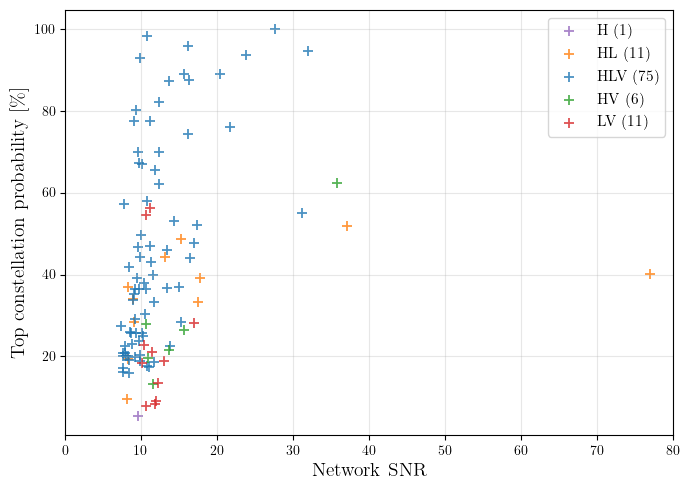

In [48]:
from astropy.table import Table
from astropy_healpix import uniq_to_level_ipix, level_to_nside
from astropy.coordinates import SkyCoord
from astropy import units as u
from collections import defaultdict

import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import os

# Compute probability in most probable constellation

def compute_pmax(skymap):

    t = Table.read(skymap)

    level, ipix = uniq_to_level_ipix(t["UNIQ"])

    nside = level_to_nside(level)

    theta, phi = hp.pix2ang(
        nside,
        ipix,
        nest=True
    )

    ra = np.degrees(phi)
    dec = 90.0 - np.degrees(theta)

    coords = SkyCoord(
        ra*u.deg,
        dec*u.deg,
        frame="icrs"
    )

    const = coords.get_constellation()

    area = hp.nside2pixarea(nside)

    prob = t["PROBDENSITY"] * area

    pconst = defaultdict(float)

    for c, p in zip(const, prob):
        pconst[c] += p

    return 100.0 * max(pconst.values())

# Detector network dictionary

inst = {
'GW240413_022019':'HLV',
'GW240414_054515':'HV',
'GW240420_175625':'H',
'GW240426_031451':'HL',
'GW240428_225440':'HV',
'GW240501_033534':'HLV',
'GW240505_133552':'HLV',
'GW240507_041632':'HLV',
'GW240511_031507':'HLV',
'GW240512_024139':'HLV',
'GW240513_183302':'HLV',
'GW240514_121713':'HLV',
'GW240515_005301':'HLV',
'GW240519_012815':'LV',
'GW240520_213616':'HLV',
'GW240525_031210':'HLV',
'GW240526_093944':'HLV',
'GW240527_183429':'HLV',
'GW240527_230910':'HLV',
'GW240530_012417':'HLV',
'GW240531_040326':'HLV',
'GW240531_075248':'HLV',
'GW240601_061200':'HL',
'GW240601_231004':'HLV',
'GW240612_081540':'HLV',
'GW240615_113620':'HLV',
'GW240615_160735':'HLV',
'GW240618_071627':'HL',
'GW240621_195059':'HLV',
'GW240621_200935':'HLV',
'GW240621_214041':'HLV',
'GW240622_004008':'HLV',
'GW240627_131622':'HLV',
'GW240629_145256':'HLV',
'GW240630_101703':'HLV',
'GW240703_191355':'LV',
'GW240705_053215':'HLV',
'GW240716_034900':'LV',
'GW240824_205609':'HLV',
'GW240825_055146':'HLV',
'GW240830_211120':'HLV',
'GW240902_143306':'HLV',
'GW240907_153833':'HLV',
'GW240908_082628':'HLV',
'GW240908_125134':'HLV',
'GW240910_103535':'HL',
'GW240915_001357':'HLV',
'GW240915_105151':'HV',
'GW240916_184352':'HLV',
'GW240919_061559':'HLV',
'GW240920_073424':'HLV',
'GW240920_124024':'HL',
'GW240921_201835':'LV',
'GW240922_142106':'HLV',
'GW240923_204006':'HLV',
'GW240924_000316':'HLV',
'GW240925_005809':'HLV',
'GW240930_035959':'HLV',
'GW240930_234614':'HL',
'GW241002_030559':'LV',
'GW241006_015333':'HLV',
'GW241007_082943':'HLV',
'GW241009_022835':'HLV',
'GW241009_084816':'HLV',
'GW241009_220455':'HLV',
'GW241011_233834':'HV',
'GW241101_220523':'LV',
'GW241102_124058':'HLV',
'GW241102_144729':'HLV',
'GW241109_033317':'LV',
'GW241109_115924':'HV',
'GW241110_124123':'HLV',
'GW241111_111552':'HL',
'GW241113_163507':'LV',
'GW241114_024711':'HLV',
'GW241114_235258':'LV',
'GW241116_151753':'HLV',
'GW241124_024914':'HLV',
'GW241125_010116':'HLV',
'GW241127_061008':'HLV',
'GW241129_021832':'HLV',
'GW241130_034908':'HLV',
'GW241130_110422':'HLV',
'GW241201_055758':'HLV',
'GW241210_060606':'HLV',
'GW241210_120900':'HL',
'GW241225_042553':'LV',
'GW241225_082815':'HL',
'GW241229_155844':'HLV',
'GW241230_084504':'LV',
'GW241230_233618':'HLV',
'GW241231_054133':'HLV',
'GW250101_011205':'HLV',
'GW250104_015122':'HLV',
'GW250108_152221':'HLV',
'GW250109_010541':'HLV',
'GW250109_074552':'HV',
'GW250114_082203':'HL',
'GW250116_015318':'HLV',
'GW250118_023225':'HLV',
'GW250118_055802':'HLV',
'GW250118_170523':'HL',
'GW250119_025138':'HLV',
'GW250119_190238':'HLV'
}

# Compute results

results = []

for _, row in df.iterrows():

    skymap = os.path.join(
        "skymaps",
        row["skymap_result_file_name"]
    )

    try:

        pmax = compute_pmax(skymap)

        results.append({
            "gw_name": row["gw_name"],
            "snr": row["network_matched_filter_snr_median"],
            "pmax": pmax,
            "inst": inst.get(row["gw_name"], "Unknown")
        })

    except Exception as e:

        print(f"Failed: {row['gw_name']}")
        print(e)

results = pd.DataFrame(results)

print(results["inst"].value_counts())


plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

colors = {
    "HLV": "tab:blue",
    "HL": "tab:orange",
    "HV": "tab:green",
    "LV": "tab:red",
    "H": "tab:purple"
}

plt.figure(figsize=(7,5))

for net, group in results.groupby("inst"):

    plt.scatter(
        group["snr"],
        group["pmax"],
        marker=("+"),
        color=colors.get(net, "black"),
        s=55,
        alpha=0.8,
        linewidths=1.3,
        label=f"{net} ({len(group)})"
    )

plt.xlabel("Network SNR", fontsize=14)
plt.ylabel(r"Top constellation probability [\%]", fontsize=14)
plt.xlim(0,80)

plt.grid(alpha=0.3)

plt.legend(fontsize=11, ncol=1)

plt.tight_layout()

plt.savefig(
    "constellation_vs_SNR_GWTC5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Probability contained in the dominant constellation as a function of the network matched-filter SNR for the 104 GWTC-5 events analysed with the IMRPhenomXPNR waveform model. 
# Each point corresponds to one gravitational-wave event. 
# The dominant constellation probability was computed from the published sky localisation maps.